In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [ ]:
# Read dataset
df = pd.read_csv("citrus.csv")

print(df.head())
print(df.info())

     name  diameter  weight  red  green  blue
0  orange      2.96   86.76  172     85     2
1  orange      3.91   88.05  166     78     3
2  orange      4.42   95.17  156     81     2
3  orange      4.47   95.60  163     81     4
4  orange      4.48   95.76  161     72     9
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  str    
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 468.9 KB
None


In [ ]:
# Encode label (orange/grape)
le = LabelEncoder()
df["name"] = le.fit_transform(df["name"])  
# grape=0, orange=1 (or reverse depending on data order)

In [ ]:
# Features and target
X = df.drop("name", axis=1)
y = df["name"]

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ==================================================
# 1. DECISION TREE
# ==================================================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

# ==================================================
# 2. NAIVE BAYES
# ==================================================
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))

# ==================================================
# 3. SUPPORT VECTOR MACHINE
# ==================================================
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

=== Decision Tree ===
Accuracy: 0.9384
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1228
           1       0.95      0.93      0.94      1272

    accuracy                           0.94      2500
   macro avg       0.94      0.94      0.94      2500
weighted avg       0.94      0.94      0.94      2500

[[1163   65]
 [  89 1183]]
=== Naive Bayes ===
Accuracy: 0.9208
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1228
           1       0.93      0.91      0.92      1272

    accuracy                           0.92      2500
   macro avg       0.92      0.92      0.92      2500
weighted avg       0.92      0.92      0.92      2500

[[1143   85]
 [ 113 1159]]
=== SVM ===
Accuracy: 0.9256
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1228
           1       0.93      0.92      0.93      1272

    accuracy           

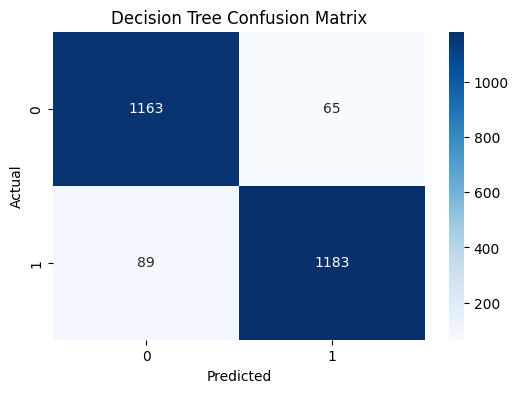

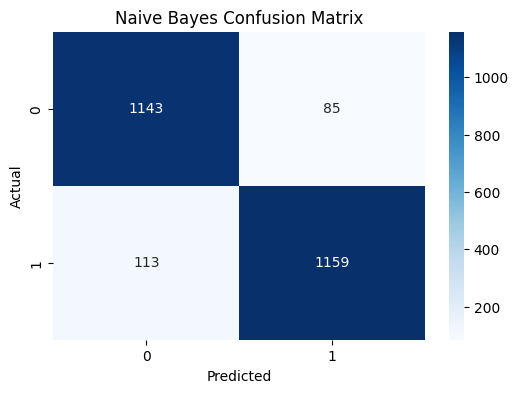

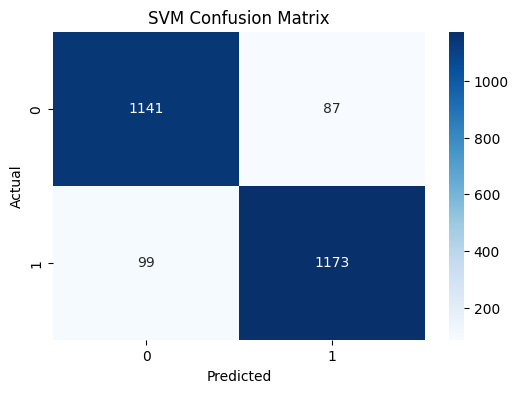

In [ ]:
# Confusion Matrix Heatmap

# ==================================================
# 1. DECISION TREE
# ==================================================
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==================================================
# 2. NAIVE BAYES
# ==================================================
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==================================================
# 3. SUPPORT VECTOR MACHINE
# ==================================================
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

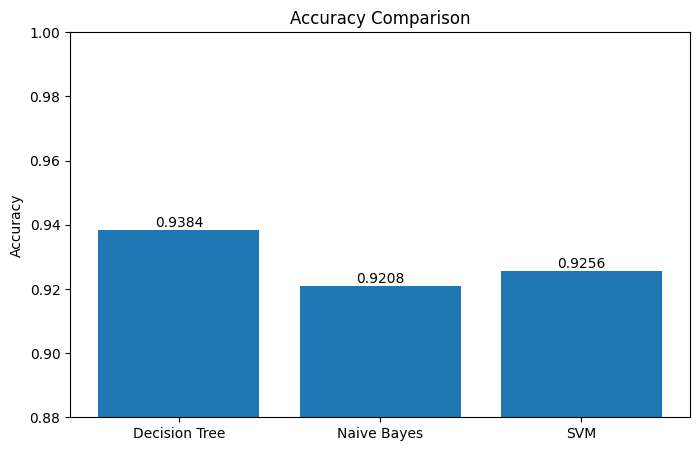

In [ ]:
# Accuracy Comparison Bar Chart
models = ['Decision Tree', 'Naive Bayes', 'SVM']
scores = [0.9384, 0.9208, 0.9256]

plt.figure(figsize=(8,5))
bars = plt.bar(models, scores)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.001, round(y,4), ha='center')

plt.ylim(0.88,1.0)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()